#### Importing the necessary libraries

In [1]:
import duckdb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import confusion_matrix



#### Connect this notebook with DuckDB database

In [3]:

DB_PATH = "../data/airline_loyalty.duckdb"

con = duckdb.connect(DB_PATH, read_only=True)

print("DuckDB connected successfully.")

DuckDB connected successfully.


#### Load the analytical customer table

In [4]:
df = con.execute("""
    SELECT
        s.customer_id,

        -- Behavioral metrics
        s.observed_months,
        s.active_months,
        s.total_flights,
        s.total_distance,
        s.avg_monthly_flights,
        s.avg_monthly_distance,
        s.total_points_accumulated,
        s.total_points_redeemed,
        s.redemption_months,

        -- Customer value/profile
        s.clv,
        s.loyalty_card,
        s.enrollment_type,
        s.has_cancellation,

        -- Segmentation
        s.engagement_score,
        s.engagement_segment,
        s.value_segment,

        -- Churn
        c.churn_status,
        c.months_to_cancellation

    FROM customer_segments s
    INNER JOIN customer_churn c
        ON s.customer_id = c.customer_id
""").df()

df.head()

,customer_id,observed_months,active_months,total_flights,total_distance,avg_monthly_flights,avg_monthly_distance,total_points_accumulated,total_points_redeemed,redemption_months,clv,loyalty_card,enrollment_type,has_cancellation,engagement_score,engagement_segment,value_segment,churn_status,months_to_cancellation
0,365346,24,15,41.0,67765.0,1.708333,2823.541667,67765.0,862.0,2,1898.01,Star,Standard,False,74.60,Engaged,Low Value,not_churned,<NA>
1,975531,24,1,2.0,3328.0,0.083333,138.666667,3328.0,0.0,0,1898.01,Star,Standard,False,10.03,Very Low Engagement,Low Value,not_churned,<NA>
2,717100,24,15,47.0,79515.0,1.958333,3313.125000,79515.0,1797.0,3,1898.68,Star,Standard,True,83.26,Highly Engaged,Low Value,churned,67
3,345518,24,13,38.0,50573.0,1.583333,2107.208333,50573.0,380.0,1,1898.68,Star,Standard,False,54.97,Engaged,Low Value,not_churned,<NA>
4,174666,24,1,4.0,4184.0,0.166667,174.333333,4184.0,0.0,0,1904.00,Star,Standard,False,10.75,Very Low Engagement,Low Value,not_churned,<NA>


#### Basic Validations

In [6]:
print(f"Rows: {len(df):,}")
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"Missing values: {df.isna().sum().sum():,}")

Rows: 16,737
Unique customers: 16,737
Missing values: 14,670


##### Checking if churned customers behave differently?

In [7]:
df["is_churned"] = (df["churn_status"] == "churned").astype(int)

In [8]:
comparison = (
    df.groupby("churn_status")[
        [
            "total_flights",
            "active_months",
            "total_distance",
            "total_points_redeemed",
            "redemption_months",
            "clv",
            "engagement_score",
        ]
    ]
    .agg(["count", "mean", "median"])
)

comparison

total_flights                   active_months                    \
                     count       mean median         count       mean median   
churn_status                                                                   
churned               2067  10.126754    3.0          2067   3.167876    2.0   
not_churned          14670  33.256714   35.0         14670  11.685412   13.0   

             total_distance                        total_points_redeemed  ...  \
                      count          mean   median                 count  ...   
churn_status                                                              ...   
churned                2067  15294.675375   4740.0                  2067  ...   
not_churned           14670  49846.465781  52245.5                 14670  ...   

                    redemption_months                     clv               \
             median             count      mean median  count         mean   
churn_status                                                                 
churned         0.0              2067  0.421384    0.0   2067  8131.776768   
not_churned   661.0             14670  1.567962    1.0  14670  7968.764740   

                      engagement_score                     
               median            count       mean  median  
churn_status                                               
churned       5793.16             2067  14.928602  11.150  
not_churned   5776.34            14670  53.026022  55.335  

[2 rows x 21 columns]

##### Exploratory data analysis

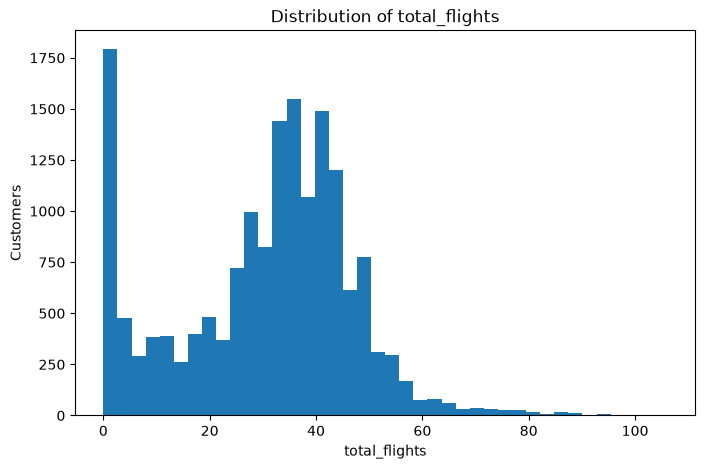

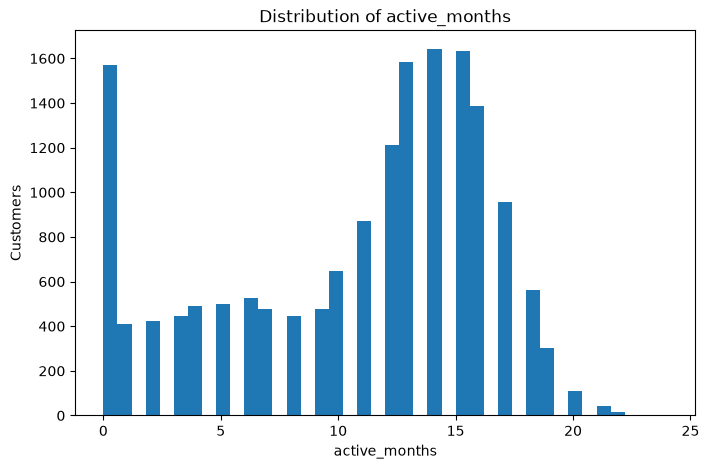

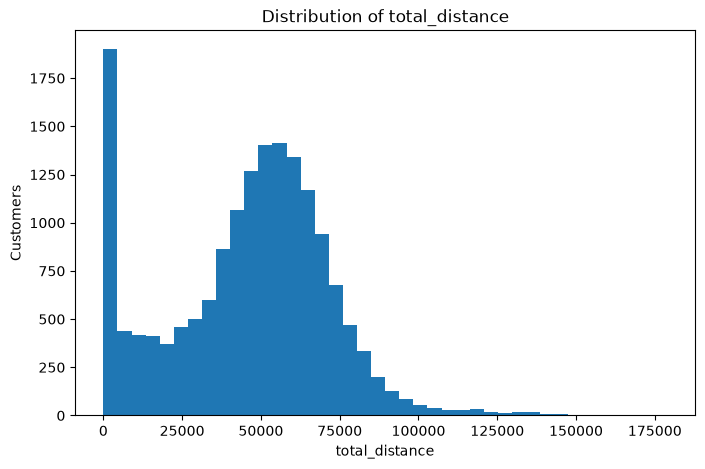

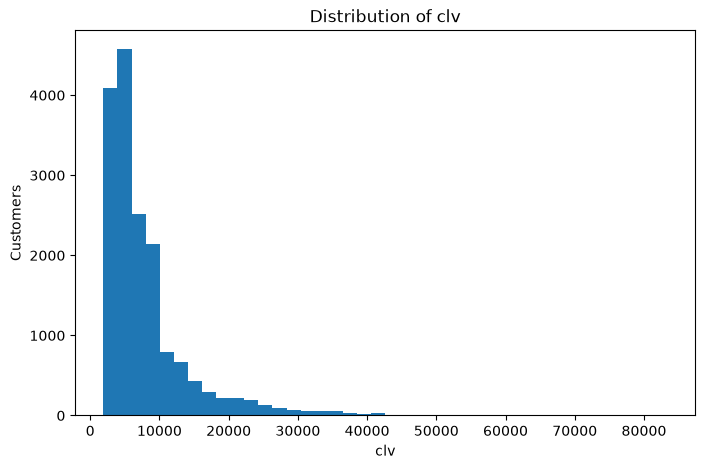

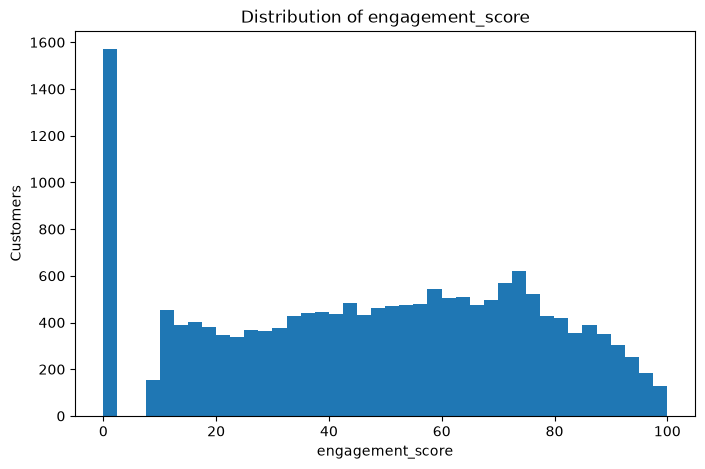

In [9]:
metrics = [
    "total_flights",
    "active_months",
    "total_distance",
    "clv",
    "engagement_score",
]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.hist(df[metric].dropna(), bins=40)
    plt.title(f"Distribution of {metric}")
    plt.xlabel(metric)
    plt.ylabel("Customers")
    plt.show()

#### Mann–Whitney U analysis

In [10]:

metrics = [
    "total_flights",
    "active_months",
    "total_distance",
    "total_points_redeemed",
    "redemption_months",
    "clv",
    "engagement_score",
]

results = []

for metric in metrics:
    churned = df.loc[df["is_churned"] == 1, metric].dropna()
    not_churned = df.loc[df["is_churned"] == 0, metric].dropna()

    statistic, p_value = mannwhitneyu(
        churned,
        not_churned,
        alternative="two-sided"
    )

    results.append({
        "metric": metric,
        "churned_median": churned.median(),
        "not_churned_median": not_churned.median(),
        "u_statistic": statistic,
        "p_value": p_value
    })

mw_results = pd.DataFrame(results)

mw_results["significant"] = mw_results["p_value"] < 0.05

mw_results.sort_values("p_value")

mw_results

,metric,churned_median,not_churned_median,u_statistic,p_value,significant
0,total_flights,3.00,35.000,4105664.5,0.000000,True
1,active_months,2.00,13.000,3441131.0,0.000000,True
2,total_distance,4740.00,52245.500,4213179.0,0.000000,True
3,total_points_redeemed,0.00,661.000,7133906.5,0.000000,True
4,redemption_months,0.00,1.000,7119435.5,0.000000,True
5,clv,5793.16,5776.340,15290877.5,0.529117,False
6,engagement_score,11.15,55.335,3795475.0,0.000000,True


##### We'll use the Cliff's delta which works well with the non-parametric Mann-Whitney test to check how large is the difference

In [11]:
def cliffs_delta(u_statistic, n_churned, n_not_churned):
    return (2 * u_statistic / (n_churned * n_not_churned)) - 1


n_churned = (df["is_churned"] == 1).sum()
n_not_churned = (df["is_churned"] == 0).sum()

mw_results["cliffs_delta"] = mw_results.apply(
    lambda row: cliffs_delta(
        row["u_statistic"],
        n_churned,
        n_not_churned
    ),
    axis=1
)

mw_results.sort_values("p_value")

,metric,churned_median,not_churned_median,u_statistic,p_value,significant,cliffs_delta
0,total_flights,3.00,35.000,4105664.5,0.000000,True,-0.729204
1,active_months,2.00,13.000,3441131.0,0.000000,True,-0.773034
2,total_distance,4740.00,52245.500,4213179.0,0.000000,True,-0.722112
3,total_points_redeemed,0.00,661.000,7133906.5,0.000000,True,-0.529471
4,redemption_months,0.00,1.000,7119435.5,0.000000,True,-0.530425
6,engagement_score,11.15,55.335,3795475.0,0.000000,True,-0.749663
5,clv,5793.16,5776.340,15290877.5,0.529117,False,0.008537


In [12]:
def interpret_cliffs_delta(delta):
    magnitude = abs(delta)

    if magnitude < 0.147:
        return "Negligible"
    elif magnitude < 0.33:
        return "Small"
    elif magnitude < 0.474:
        return "Medium"
    else:
        return "Large"


mw_results["effect_size"] = mw_results["cliffs_delta"].apply(
    interpret_cliffs_delta
)

mw_results[
    [
        "metric",
        "churned_median",
        "not_churned_median",
        "p_value",
        "cliffs_delta",
        "effect_size",
    ]
].sort_values("cliffs_delta")

,metric,churned_median,not_churned_median,p_value,cliffs_delta,effect_size
1,active_months,2.00,13.000,0.000000,-0.773034,Large
6,engagement_score,11.15,55.335,0.000000,-0.749663,Large
0,total_flights,3.00,35.000,0.000000,-0.729204,Large
2,total_distance,4740.00,52245.500,0.000000,-0.722112,Large
4,redemption_months,0.00,1.000,0.000000,-0.530425,Large
3,total_points_redeemed,0.00,661.000,0.000000,-0.529471,Large
5,clv,5793.16,5776.340,0.529117,0.008537,Negligible


#### Segment level churn analysis

In [13]:
engagement_churn = (
    df.groupby("engagement_segment")
      .agg(
          customers=("customer_id", "count"),
          churned_customers=("is_churned", "sum"),
          churn_rate=("is_churned", "mean")
      )
      .reset_index()
)

engagement_churn["churn_rate"] *= 100

engagement_churn.sort_values("churn_rate", ascending=False)

,engagement_segment,customers,churned_customers,churn_rate
3,Very Low Engagement,4034,1662,41.199802
2,Low Engagement,4237,265,6.254425
0,Engaged,5146,112,2.176448
1,Highly Engaged,3320,28,0.843373


##### Checking the same for value segment

In [14]:
value_churn = (
    df.groupby("value_segment")
      .agg(
          customers=("customer_id", "count"),
          churned_customers=("is_churned", "sum"),
          churn_rate=("is_churned", "mean")
      )
      .reset_index()
)

value_churn["churn_rate"] *= 100

value_churn.sort_values("churn_rate", ascending=False)

,value_segment,customers,churned_customers,churn_rate
3,Mid-Low Value,4194,533,12.708631
0,High Value,4185,519,12.401434
2,Mid-High Value,4174,517,12.386200
1,Low Value,4184,498,11.902486


#### Test whether engagement segment and churn are associated

In [15]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    df["engagement_segment"],
    df["churn_status"]
)

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency
)

print(f"Chi-square statistic: {chi2:,.2f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value: {p_value:.10f}")

Chi-square statistic: 4,145.31
Degrees of freedom: 3
P-value: 0.0000000000


##### Calculate Cramér's V to measure the strength of the association

In [16]:

# Engagement segment vs churn
contingency = pd.crosstab(
    df["engagement_segment"],
    df["churn_status"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency)

n = contingency.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * min(contingency.shape[0] - 1, contingency.shape[1] - 1))
)

print("Engagement Segment vs Churn")
print("----------------------------")
print(f"Chi-square: {chi2:,.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.10f}")
print(f"Cramér's V: {cramers_v:.4f}")

Engagement Segment vs Churn
----------------------------
Chi-square: 4,145.31
Degrees of freedom: 3
P-value: 0.0000000000
Cramér's V: 0.4977


In [17]:
contingency = pd.crosstab(
    df["value_segment"],
    df["churn_status"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency)

n = contingency.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * min(contingency.shape[0] - 1, contingency.shape[1] - 1))
)

print("Value Segment vs Churn")
print("----------------------")
print(f"Chi-square: {chi2:,.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.10f}")
print(f"Cramér's V: {cramers_v:.4f}")

Value Segment vs Churn
----------------------
Chi-square: 1.29
Degrees of freedom: 3
P-value: 0.7320582871
Cramér's V: 0.0088


So the statistical analysis clearly state that customer engagement is strongly associated with churn. Customers with very low engagement have substantially higher churn risk.

#### Checking the relationship between engagement and churn

##### Step 1: Point-biserial correlation

In [18]:
corr, p_value = pointbiserialr(
    df["is_churned"],
    df["engagement_score"]
)

print(f"Point-biserial correlation: {corr:.4f}")
print(f"P-value: {p_value:.10f}")

Point-biserial correlation: -0.4520
P-value: 0.0000000000


##### Step 2: Making it business-readable

In [19]:
df["engagement_band"] = pd.cut(
    df["engagement_score"],
    bins=[-0.01, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    labels=[
        "0–10",
        "11–20",
        "21–30",
        "31–40",
        "41–50",
        "51–60",
        "61–70",
        "71–80",
        "81–90",
        "91–100"
    ],
    include_lowest=True
)

engagement_band_churn = (
    df.groupby("engagement_band", observed=False)
      .agg(
          customers=("customer_id", "count"),
          churned_customers=("is_churned", "sum"),
          churn_rate=("is_churned", "mean")
      )
      .reset_index()
)

engagement_band_churn["churn_rate"] *= 100

engagement_band_churn

,engagement_band,customers,churned_customers,churn_rate
0,0–10,1727,993,57.498552
1,11–20,1628,463,28.439803
2,21–30,1415,308,21.766784
3,31–40,1687,108,6.401897
4,41–50,1815,55,3.030303
5,51–60,1967,34,1.728521
6,61–70,1990,43,2.160804
7,71–80,2137,44,2.058961
8,81–90,1514,15,0.990753
9,91–100,857,4,0.466744


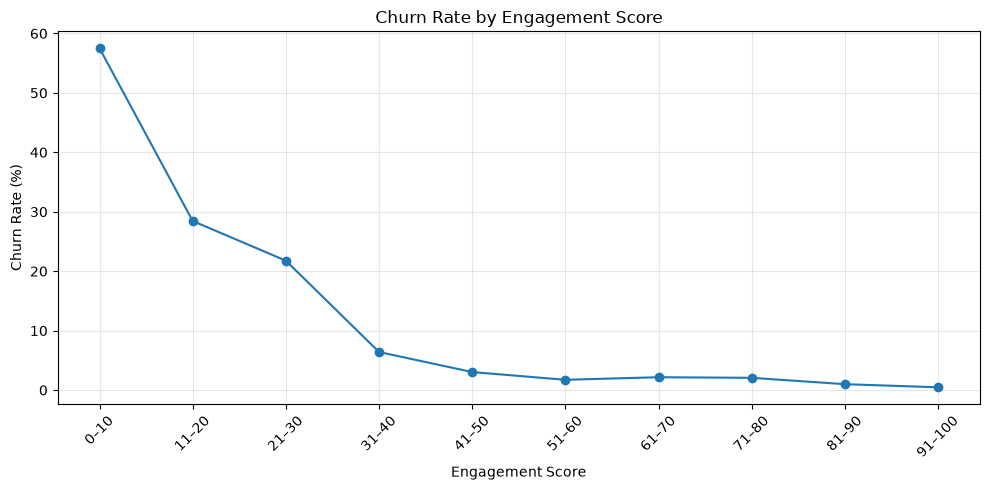

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    engagement_band_churn["engagement_band"].astype(str),
    engagement_band_churn["churn_rate"],
    marker="o"
)

plt.title("Churn Rate by Engagement Score")
plt.xlabel("Engagement Score")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Key finding

Churn is strongly concentrated among low-engagement customers. Customers
with engagement scores of 0–10 have a 57.5% observed churn rate, compared
with 0.47% among customers scoring 91–100. The relationship is strongly
negative overall (point-biserial r = -0.452, p < 0.001), although churn rates
show some variation across the middle engagement bands.

#### Build the churn prediction model

Defining the dataset with a 3 month observation window

In [21]:
# Load monthly customer activity
monthly = con.execute("""
    SELECT
        customer_id,
        activity_date,
        total_flights,
        distance,
        points_accumulated,
        points_redeemed,
        has_flight_activity,
        has_points_redeemed
    FROM fact_customer_month
    ORDER BY customer_id, activity_date
""").df()

monthly.head()

,customer_id,activity_date,total_flights,distance,points_accumulated,points_redeemed,has_flight_activity,has_points_redeemed
0,100018,2017-01-01,1,601,601.0,0,True,False
1,100018,2017-02-01,0,0,0.0,0,False,False
2,100018,2017-03-01,4,9648,9648.0,438,True,True
3,100018,2017-04-01,1,1654,1654.0,0,True,False
4,100018,2017-05-01,0,0,0.0,0,False,False


In [22]:
customers = con.execute("""
    SELECT
        customer_id,
        enrollment_date,
        cancellation_date,
        has_cancellation
    FROM dim_customer
""").df()

customers.head()

,customer_id,enrollment_date,cancellation_date,has_cancellation
0,480934,2016-02-01,NaT,False
1,549612,2016-03-01,NaT,False
2,429460,2014-07-01,2018-01-01,True
3,608370,2013-02-01,NaT,False
4,530508,2014-10-01,NaT,False


In [23]:
model_data = monthly.merge(
    customers,
    on="customer_id",
    how="left"
)

model_data.head()

,customer_id,activity_date,total_flights,distance,points_accumulated,points_redeemed,has_flight_activity,has_points_redeemed,enrollment_date,cancellation_date,has_cancellation
0,100018,2017-01-01,1,601,601.0,0,True,False,2016-08-01,NaT,False
1,100018,2017-02-01,0,0,0.0,0,False,False,2016-08-01,NaT,False
2,100018,2017-03-01,4,9648,9648.0,438,True,True,2016-08-01,NaT,False
3,100018,2017-04-01,1,1654,1654.0,0,True,False,2016-08-01,NaT,False
4,100018,2017-05-01,0,0,0.0,0,False,False,2016-08-01,NaT,False


In [24]:
model_data.shape

(389065, 11)

In [25]:
# Define the prediction month
model_data["prediction_month"] = np.where(
    model_data["has_cancellation"],
    model_data["cancellation_date"].values.astype("datetime64[M]"),
    np.datetime64("2018-12-01")
)

model_data["prediction_month"] = pd.to_datetime(
    model_data["prediction_month"]
)

# Calculate months between activity and prediction point
model_data["months_before_prediction"] = (
    (model_data["prediction_month"].dt.year - model_data["activity_date"].dt.year) * 12
    + (model_data["prediction_month"].dt.month - model_data["activity_date"].dt.month)
)

# Make sure all date columns are proper datetimes
model_data["activity_date"] = pd.to_datetime(model_data["activity_date"])
model_data["cancellation_date"] = pd.to_datetime(model_data["cancellation_date"])
model_data["prediction_month"] = pd.to_datetime(model_data["prediction_month"])

# Recalculate months before prediction
model_data["months_before_prediction"] = (
    (model_data["prediction_month"].dt.year - model_data["activity_date"].dt.year) * 12
    + (model_data["prediction_month"].dt.month - model_data["activity_date"].dt.month)
)

model_data[[
    "customer_id",
    "activity_date",
    "prediction_month",
    "months_before_prediction"
]].head()

,customer_id,activity_date,prediction_month,months_before_prediction
0,100018,2017-01-01,2018-12-01,23
1,100018,2017-02-01,2018-12-01,22
2,100018,2017-03-01,2018-12-01,21
3,100018,2017-04-01,2018-12-01,20
4,100018,2017-05-01,2018-12-01,19


In [26]:
model_data["months_before_prediction"].value_counts().sort_index().head(10)

months_before_prediction
-71     1
-70     2
-69     2
-68     3
-67     3
-66     6
-65     8
-64    11
-63    20
-62    27
Name: count, dtype: int64

In [27]:
model_data["months_before_prediction"].min(), model_data["months_before_prediction"].max()

(np.int32(-71), np.int32(23))

##### Create 3 month feature dataset

In [31]:
# Keep only the 3 months before the prediction point.
# Exclude month 0 and all post-prediction activity.
feature_window = model_data[
    model_data["months_before_prediction"].isin([1, 2, 3])
].copy()

feature_window.shape

(47230, 13)

In [32]:
feature_window = feature_window[
    feature_window["activity_date"] >= feature_window["enrollment_date"]
].copy()

In [33]:
model_features = (
    feature_window
    .groupby("customer_id")
    .agg(
        flights_3m=("total_flights", "sum"),
        distance_3m=("distance", "sum"),
        points_accumulated_3m=("points_accumulated", "sum"),
        points_redeemed_3m=("points_redeemed", "sum"),
        active_months_3m=("has_flight_activity", "sum"),
        redemption_months_3m=("has_points_redeemed", "sum"),
        feature_months=("activity_date", "nunique")
    )
    .reset_index()
)

In [34]:
model_features = model_features.merge(
    customers[["customer_id", "has_cancellation"]],
    on="customer_id",
    how="left"
)

model_features["is_churned"] = (
    model_features["has_cancellation"]
).astype(int)

In [36]:
model_features["is_churned"].value_counts()

is_churned
0    14432
1     1104
Name: count, dtype: int64

In [37]:
model_features["feature_months"].value_counts().sort_index()

feature_months
1      287
2      253
3    14996
Name: count, dtype: int64

Keep only complete feature windows

In [38]:
model_features = model_features[
    model_features["feature_months"] == 3
].copy()

In [40]:
model_features["is_churned"].value_counts()

is_churned
0    13974
1     1022
Name: count, dtype: int64

Now prepare featuers and targets

In [41]:
feature_cols = [
    "flights_3m",
    "distance_3m",
    "points_accumulated_3m",
    "points_redeemed_3m",
    "active_months_3m",
    "redemption_months_3m"
]

X = model_features[feature_cols]
y = model_features["is_churned"]

X.shape, y.shape

((14996, 6), (14996,))

Train - Test split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((11996, 6), (3000, 6))

In [43]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(is_churned
 0    0.931811
 1    0.068189
 Name: proportion, dtype: float64,
 is_churned
 0    0.932
 1    0.068
 Name: proportion, dtype: float64)

Train logistic regression

In [44]:


logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['flights_3m','distance_3m','points_accumulated_3m','points_redeemed_3m', 'active_months_3m','redemption_months_3m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Running the predictions

In [45]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

Evaluating the model

In [46]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"ROC-AUC:  {roc_auc:.3f}")
print(f"PR-AUC:   {pr_auc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")

ROC-AUC:  0.639
PR-AUC:   0.221
Precision: 0.889
Recall:    0.039
F1:        0.075


Examine model coefficients

In [47]:
coefficients = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": logistic_model.named_steps["model"].coef_[0]
})

coefficients["odds_ratio"] = np.exp(coefficients["coefficient"])

coefficients.sort_values(
    "coefficient",
    ascending=False
)

,feature,coefficient,odds_ratio
3,points_redeemed_3m,1.463392,4.320590
0,flights_3m,0.781981,2.185798
1,distance_3m,0.695218,2.004147
4,active_months_3m,-0.515282,0.597332
2,points_accumulated_3m,-0.788539,0.454508
5,redemption_months_3m,-1.549321,0.212392


Checking the feature correlation

In [48]:
X.corr().round(2)

,flights_3m,distance_3m,points_accumulated_3m,points_redeemed_3m,active_months_3m,redemption_months_3m
flights_3m,1.00,0.91,0.90,0.13,0.72,0.12
distance_3m,0.91,1.00,0.97,0.11,0.65,0.11
points_accumulated_3m,0.90,0.97,1.00,0.10,0.55,0.09
points_redeemed_3m,0.13,0.11,0.10,1.00,0.18,0.98
active_months_3m,0.72,0.65,0.55,0.18,1.00,0.18
redemption_months_3m,0.12,0.11,0.09,0.98,0.18,1.00


In [54]:
threshold_results = []

for threshold in np.arange(0.05, 0.51, 0.05):
    predictions = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,threshold,precision,recall,f1
0,0.05,0.075,0.779,0.137
1,0.10,0.181,0.363,0.242
2,0.15,0.304,0.172,0.219
3,0.20,0.478,0.108,0.176
4,0.25,0.621,0.088,0.155
5,0.30,0.750,0.074,0.134
6,0.35,0.786,0.054,0.101
7,0.40,0.909,0.049,0.093
8,0.45,0.900,0.044,0.084
9,0.50,0.889,0.039,0.075


Confusion Matrix

In [55]:
threshold = 0.10

y_pred_010 = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_010)

cm

array([[2462,  334],
       [ 130,   74]])

In [56]:
tn, fp, fn, tp = cm.ravel()

print(f"True negatives:  {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives:  {tp}")

True negatives:  2462
False positives: 334
False negatives: 130
True positives:  74


In [57]:
test_results = model_features.loc[
    X_test.index,
    ["customer_id", "is_churned"]
].copy()

test_results["churn_probability"] = y_prob
test_results["predicted_churn_010"] = y_pred_010

test_results.head()

,customer_id,is_churned,churn_probability,predicted_churn_010
4090,338872,0,0.052302,0
10801,723347,0,0.066183,0
646,137858,1,0.263167,1
6561,480934,0,0.064316,0
8601,597294,0,0.049131,0


Customer Risk scores

In [59]:
customer_risk = model_features[
    ["customer_id", "is_churned"]
].copy()

customer_risk["churn_probability"] = logistic_model.predict_proba(
    model_features[feature_cols]
)[:, 1]

customer_risk["predicted_churn_010"] = (
    customer_risk["churn_probability"] >= 0.10
).astype(int)

customer_risk.head()

,customer_id,is_churned,churn_probability,predicted_churn_010
0,100018,0,0.051924,0
1,100102,0,0.096389,0
2,100140,0,0.063180,0
3,100214,0,0.087157,0
4,100272,0,0.049570,0


Risk Bands

In [60]:
customer_risk["risk_band"] = pd.cut(
    customer_risk["churn_probability"],
    bins=[0, 0.10, 0.20, 0.40, 1.00],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ],
    include_lowest=True
)

In [61]:
customer_risk["risk_band"].value_counts().sort_index()

risk_band
Low Risk          13022
Moderate Risk      1778
High Risk           150
Very High Risk       46
Name: count, dtype: int64

Saving the model output

In [62]:
customer_risk.to_parquet(
    "../data/processed/customer_churn_risk.parquet",
    index=False
)